<a href="https://colab.research.google.com/github/sukrit2906/subhamaverick/blob/main/IZFT_QAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Delay-Doppler Grid Shape: (8, 8)
Time-domain Signal Length: 64


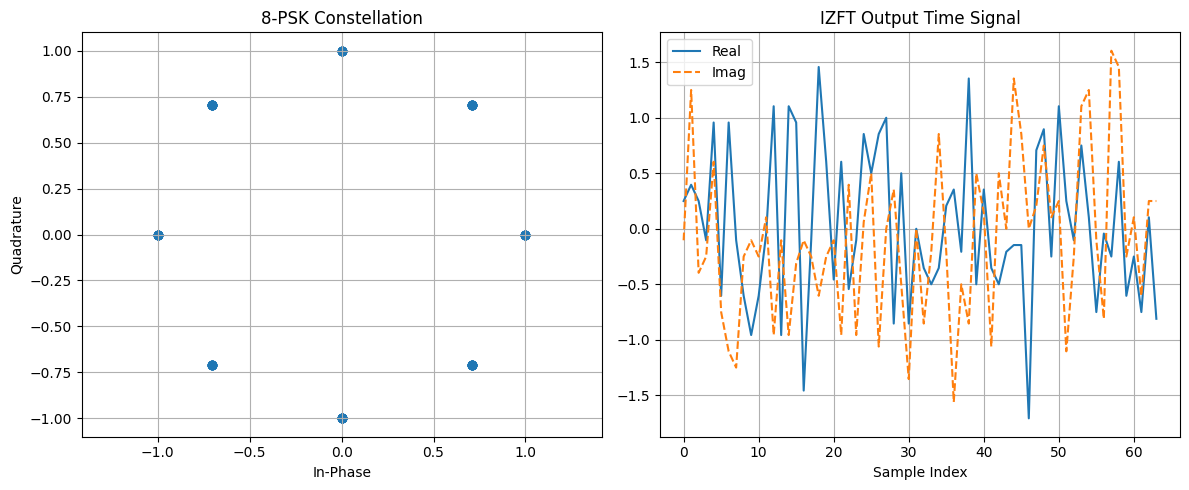

In [4]:

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
N_delay = 8          # Delay bins
M_doppler = 8        # Doppler bins
PSK_order = 8        # 2=BPSK, 4=QPSK, 8=8PSK, etc.

# -----------------------------
# Generate random symbols
# -----------------------------
bits_per_symbol = int(np.log2(PSK_order))
num_symbols = N_delay * M_doppler

# Random bit stream
bits = np.random.randint(0, 2, num_symbols * bits_per_symbol)

# Convert bits to integers
symbols_decimal = bits.reshape((-1, bits_per_symbol))
symbols_decimal = symbols_decimal.dot(
    2 ** np.arange(bits_per_symbol - 1, -1, -1)
)

# -----------------------------
# N-PSK Modulation
# -----------------------------
psk_symbols = np.exp(1j * 2 * np.pi * symbols_decimal / PSK_order)

# Arrange into Delay-Doppler grid
X_DD = psk_symbols.reshape((N_delay, M_doppler))

# -----------------------------
# Inverse Zak Transform (IZFT)
# -----------------------------
# IFFT along Doppler dimension
X_ifft = np.fft.ifft(X_DD, axis=1, norm="ortho")

# Serialize row-wise
tx_signal = X_ifft.reshape(-1)

# -----------------------------
# Display Results
# -----------------------------
print("Delay-Doppler Grid Shape:", X_DD.shape)
print("Time-domain Signal Length:", len(tx_signal))

# -----------------------------
# Plots
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(psk_symbols.real, psk_symbols.imag)
plt.grid(True)
plt.axis('equal')
plt.title(f"{PSK_order}-PSK Constellation")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")

plt.subplot(1,2,2)
plt.plot(np.real(tx_signal), label='Real')
plt.plot(np.imag(tx_signal), label='Imag', linestyle='--')
plt.grid(True)
plt.title("IZFT Output Time Signal")
plt.xlabel("Sample Index")
plt.legend()

plt.tight_layout()
plt.show()

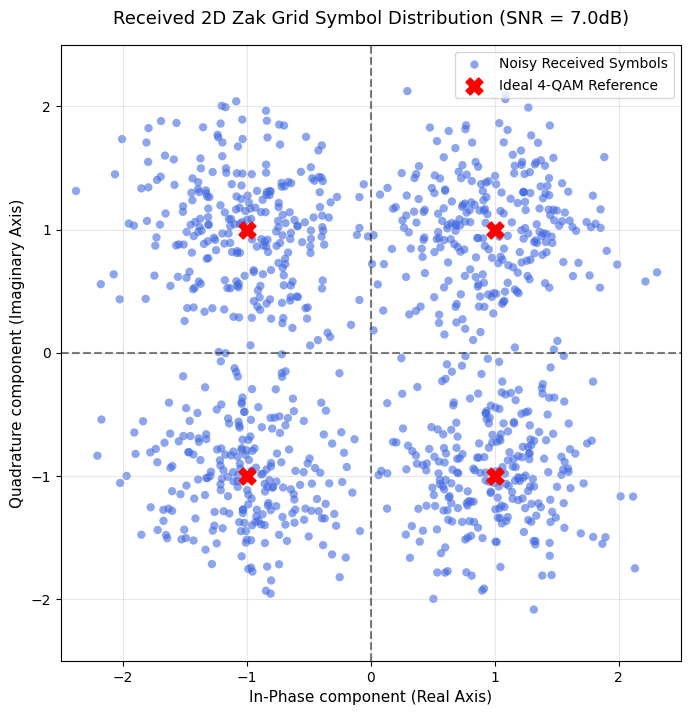

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def transmit_pipeline_izft(binary_data, num_time_blocks=4, num_freq_bins=8):
    """Maps raw binary bits onto 2D Zak space and synthesizes 1D waveform."""
    qam_mapping = {(0,0): 1+1j, (0,1): -1+1j, (1,1): -1-1j, (1,0): 1-1j}
    symbols = [qam_mapping[tuple(binary_data[i:i+2])] for i in range(0, len(binary_data), 2)]
    zak_matrix = np.array(symbols).reshape(num_time_blocks, num_freq_bins)
    time_blocks = np.fft.ifft(zak_matrix, axis=1) * num_freq_bins
    return zak_matrix, time_blocks.flatten()

def inject_awgn_noise(tx_signal, snr_db):
    """Injects complex additive white Gaussian noise (AWGN) onto a 1D signal."""
    signal_power = np.mean(np.abs(tx_signal)**2)
    snr_linear = 10 ** (snr_db / 10.0)
    noise_power = signal_power / snr_linear

    noise_real = np.random.normal(0, np.sqrt(noise_power / 2.0), len(tx_signal))
    noise_imag = np.random.normal(0, np.sqrt(noise_power / 2.0), len(tx_signal))
    return tx_signal + (noise_real + 1j * noise_imag)

def receive_pipeline_zft(transmit_waveform, num_time_blocks=4, num_freq_bins=8):
    """Slices 1D array back into 2D time blocks and applies row-wise FFT."""
    time_blocks = transmit_waveform.reshape(num_time_blocks, num_freq_bins)
    recovered_zak_matrix = np.fft.fft(time_blocks, axis=1) / num_freq_bins

    recovered_symbols = recovered_zak_matrix.flatten()
    recovered_bits = []
    for symbol in recovered_symbols:
        b1 = 0 if symbol.real >= 0 else 1
        b2 = 0 if symbol.imag >= 0 else 1
        recovered_bits.extend([b1, b2])
    return np.array(recovered_bits), recovered_zak_matrix

# --- Main Simulation Execution ---
if __name__ == "__main__":
    np.random.seed(42)

    # 1. Setup dimensions (40 coarse time frames x 25 frequency bins = 1000 QAM symbols)
    N_blocks, M_bins = 40, 25
    original_bits = np.random.randint(0, 2, N_blocks * M_bins * 2)

    # 2. Transmitter (IZFT)
    _, tx_waveform = transmit_pipeline_izft(original_bits, N_blocks, M_bins)

    # 3. Channel Impairments (Add 7 dB of Noise)
    snr_target = 7.0
    rx_waveform = inject_awgn_noise(tx_waveform, snr_target)

    # 4. Receiver (ZFT)
    decoded_bits, received_grid = receive_pipeline_zft(rx_waveform, N_blocks, M_bins)

    # --- 5. Generate the Plot ---
    # Flatten the 2D matrix back into symbols to plot on a complex 2D cartesian plane
    received_symbols = received_grid.flatten()

    plt.figure(figsize=(8, 8))

    # Plot the noisy points in blue
    plt.scatter(received_symbols.real, received_symbols.imag,
                color='royalblue', alpha=0.6, edgecolors='none', label='Noisy Received Symbols')

    # Plot the clean, ideal target constellation points (centers) in red
    ideal_points = [1+1j, -1+1j, -1-1j, 1-1j]
    plt.scatter([p.real for p in ideal_points], [p.imag for p in ideal_points],
                color='red', marker='X', s=150, zorder=5, label='Ideal 4-QAM Reference')

    # Draw decision boundary helper axes lines
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)

    # Format labels, ranges, and text properties
    plt.title(f'Received 2D Zak Grid Symbol Distribution (SNR = {snr_target}dB)', fontsize=13, pad=15)
    plt.xlabel('In-Phase component (Real Axis)', fontsize=11)
    plt.ylabel('Quadrature component (Imaginary Axis)', fontsize=11)
    plt.xlim([-2.5, 2.5])
    plt.ylim([-2.5, 2.5])
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')

    # Render the chart window
    plt.show()
